### Nepal Daily Climate Data Analysis (1981–2019)
Climate change has become one of the biggest environmental challenges worldwide. Nepal has experienced changing temperatures and rainfall patterns over the last few decades. This project analyzes Nepal's daily climate data from 1981–2019 to identify long-term climate trends.
 ## Objective

 The objective of this project is to clean, explore, and analyze Nepal's daily climate dataset using Python and Plotly. The analysis focuses on understanding temperature trends, rainfall patterns, district and province comparisons, and seasonal climate variations through exploratory data analysis and interactive visualizations.

 **Tools Used**
 - Python
 - Pandas
 - Plotly
 - Matplotlib
 - Statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px

 #### 1. Data Cleaning

Before analyzing the dataset, it is important to ensure that the data is accurate and reliable. 
This section removes duplicate records, handles missing values, checks for invalid climate measurements, and prepares the dataset for analysis 
by creating additional time-based features.

In [16]:
df = pd.read_csv(r"C:\Users\LOQ\Downloads\dailyclimate.csv.zip")

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("Shape:", df.shape)
df.head()


Shape: (883128, 22)


,Date,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,...,TempRange_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeedRange_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,WindSpeedRange_50m
0,1981-01-01,Arghakhanchi,27.9,83.2,0.00,93.51,4.81,45.41,13.89,2.15,...,10.89,11.32,1.89,3.83,0.69,3.14,2.41,4.12,0.73,3.39
1,1981-01-02,Arghakhanchi,27.9,83.2,0.00,93.59,4.94,46.78,13.84,2.54,...,11.17,11.44,1.72,2.60,1.09,1.50,2.25,3.30,0.96,2.34
2,1981-01-03,Arghakhanchi,27.9,83.2,0.03,93.55,5.22,47.91,14.33,3.32,...,9.93,12.24,1.80,2.80,0.48,2.32,2.32,3.54,0.39,3.15
3,1981-01-04,Arghakhanchi,27.9,83.2,0.02,93.49,5.36,50.83,13.82,3.73,...,10.41,12.17,2.18,3.54,1.06,2.49,2.90,4.05,0.93,3.12
4,1981-01-05,Arghakhanchi,27.9,83.2,1.84,93.49,5.84,55.55,13.76,4.93,...,10.53,12.32,1.96,2.70,0.69,2.02,2.74,4.64,0.96,3.68


In [17]:
rows_before = len(df)

#Removing missing values, error codes, negative rainfall, filtering temperature range
df = df.drop_duplicates(subset=['District', 'Date'])
df = df.dropna()
df = df[df['Precip'] > -900]
df = df[df['Temp_2m'] > -900]
df = df[df['Precip'] >= 0]
df = df[(df['Temp_2m'] >= -50) & (df['Temp_2m'] <= 55)]

#Converting date , extracting year, month 
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print("Rows before:", rows_before)
print("Rows after:", len(df))

Rows before: 883128
Rows after: 883128


 ### Data Cleaning Summary

The dataset was successfully cleaned by:

- Removing duplicate records.
- Handling missing values.
- Removing invalid climate measurements.
- Converting the Date column to datetime format.
- Creating Year and Month columns for time-based analysis.

The cleaned dataset is now ready for exploratory data analysis.

### 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the characteristics of the dataset before performing detailed analysis. 
In this section, we examine data distributions, identify outliers, and explore relationships between climate variables.

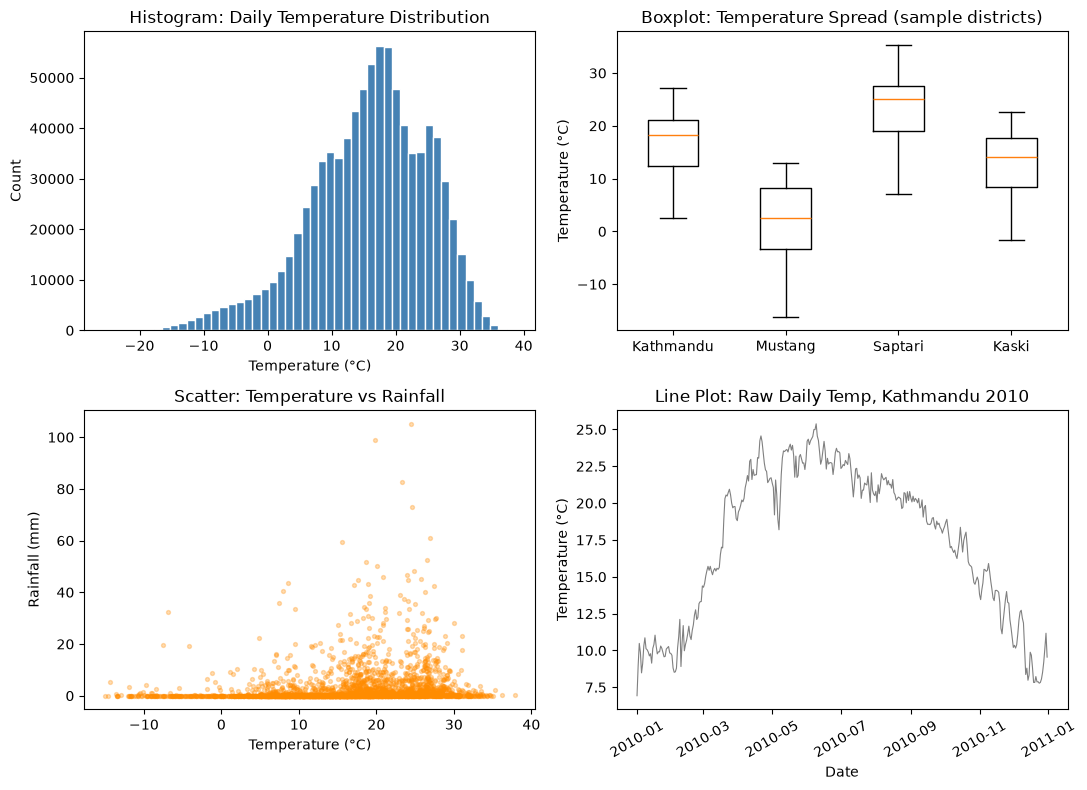

In [18]:
# ===== EDA: Exploratory Data Analysis =====
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# 1. Histogram  
axes[0,0].hist(df['Temp_2m'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Histogram: Daily Temperature Distribution')
axes[0,0].set_xlabel('Temperature (°C)'); axes[0,0].set_ylabel('Count')

# 2. Boxplot (rough look, just a few sample districts)
sample_districts = ['Kathmandu','Mustang','Saptari','Kaski']
data = [df[df['District']==d]['Temp_2m'].values for d in sample_districts]
axes[0,1].boxplot(data, tick_labels=sample_districts) 
axes[0,1].set_title('Boxplot: Temperature Spread (sample districts)')
axes[0,1].set_ylabel('Temperature (°C)')

# 3. Scatter
sample = df.sample(3000, random_state=1)
axes[1,0].scatter(sample['Temp_2m'], sample['Precip'], alpha=0.3, s=8, color='darkorange')
axes[1,0].set_title('Scatter: Temperature vs Rainfall')
axes[1,0].set_xlabel('Temperature (°C)'); axes[1,0].set_ylabel('Rainfall (mm)')

# 4. Line plot (raw, unprocessed — one district, one year)
raw = df[(df['District']=='Kathmandu') & (df['Date'].dt.year==2010)]
axes[1,1].plot(raw['Date'], raw['Temp_2m'], color='gray', linewidth=0.8)
axes[1,1].set_title('Line Plot: Raw Daily Temp, Kathmandu 2010')
axes[1,1].set_xlabel('Date'); axes[1,1].set_ylabel('Temperature (°C)')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_grid.png', dpi=200, bbox_inches='tight')
plt.show()

### Observation

The histogram illustrates how average temperatures are distributed throughout the dataset.
Most observations fall within a moderate temperature range, while extreme temperatures occur less frequently.

### 3. Temperature Trend Analysis 
This section investigates how Nepal's average annual temperature has changes from 1981-2019.
Understanding long-term temperature trends is important for identifying possible climate changes over time

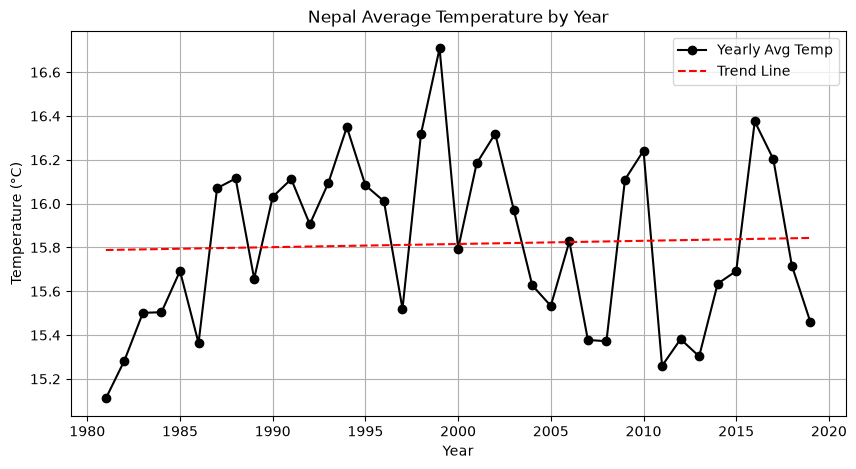

R-squared: 0.0018


<Figure size 640x480 with 0 Axes>

In [19]:
yearly_temp = df.groupby('Year')['Temp_2m'].mean()
years = yearly_temp.index
temps = yearly_temp.values

slope, intercept, r_value, p_value, std_err = stats.linregress(years, temps)

plt.figure(figsize=(10, 5))
plt.plot(years, temps, marker='o', color='black', label='Yearly Avg Temp')
plt.plot(years, intercept + slope * years, '--', color='red', label='Trend Line')
plt.title('Nepal Average Temperature by Year')
plt.xlabel('Year'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(True)
plt.show()

print("R-squared:", round(r_value**2, 4))
plt.savefig('temperature_trend.png', dpi=300, bbox_inches='tight')

### Observation 
The visualization shows annual changes in average temperature throughout the study period.
It helps identify long-term warming or cooling patterns as well as yearly fluctuations

### 4. Rainfall Trend Analysis 
Rainfall is one of the most important climate variables. This analysis explores how 
annual rainfall has varied over time across Nepal.

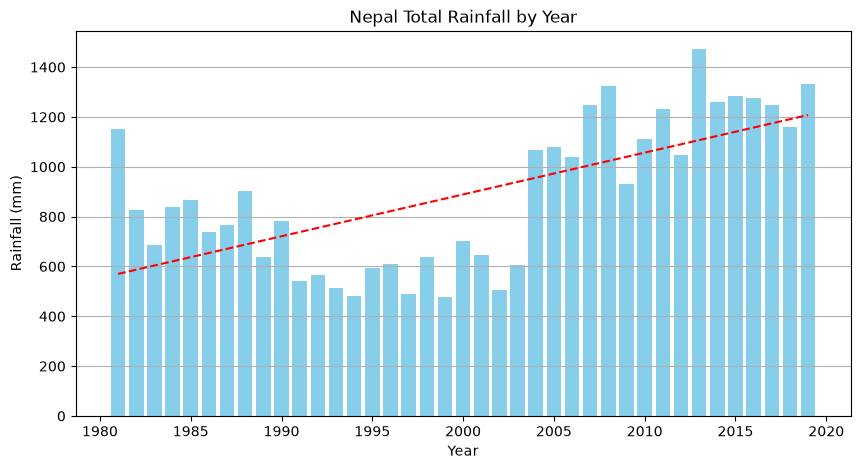

R-squared: 0.406


In [13]:
daily_rainfall = df.groupby('Date')['Precip'].mean()
yearly_rainfall = daily_rainfall.groupby(daily_rainfall.index.year).sum()

slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_rainfall.index, yearly_rainfall.values)

plt.figure(figsize=(10, 5))
plt.bar(yearly_rainfall.index, yearly_rainfall.values, color='skyblue')
plt.plot(yearly_rainfall.index, intercept + slope * yearly_rainfall.index, '--', color='red')
plt.title('Nepal Total Rainfall by Year')
plt.xlabel('Year'); plt.ylabel('Rainfall (mm)')
plt.grid(True, axis='y')
plt.show()

print("R-squared:", round(r_value**2, 4))

### Observation 
Annual rainfall varies considerably from year to year. This variability reflects the changing 
nature of Nepal's climate and seasonal weather conditions.  

### 5. Province Comparison 
This section groups Nepal's 62 distructs into their 7 provinces to compare average tempreture and rainfall regionally, rather than just nationally.

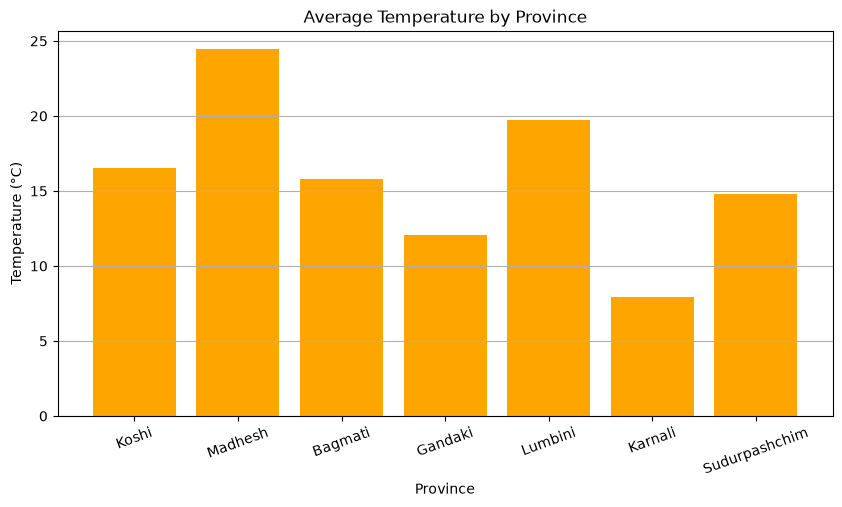

In [23]:
#district to province mapping because dataset consisted of only district column
district_to_province = {
    'Bhojpur':'Koshi','Dhankuta':'Koshi','Ilam':'Koshi','Jhapa':'Koshi','Khotang':'Koshi',
    'Morang':'Koshi','Okhaldhunga':'Koshi','Panchther':'Koshi','Sankhuwasabha':'Koshi',
    'Solukhumbu':'Koshi','Sunsari':'Koshi','Taplejung':'Koshi','Terhathum':'Koshi','Udayapur':'Koshi',
    'Bara':'Madhesh','Dhanusa':'Madhesh','Mahottari':'Madhesh','Routahat':'Madhesh',
    'Saptari':'Madhesh','Sarlahi':'Madhesh',
    'Bhaktapur':'Bagmati','Chitawan':'Bagmati','Dhading':'Bagmati','Dolkha':'Bagmati',
    'Kabhre':'Bagmati','Kathmandu':'Bagmati','Lalitpur':'Bagmati','Makwanpur':'Bagmati',
    'Nuwakot':'Bagmati','Rasuwa':'Bagmati','Sindhuli':'Bagmati',
    'Baglung':'Gandaki','Gorkha':'Gandaki','Kaski':'Gandaki','Lamjung':'Gandaki','Manang':'Gandaki',
    'Mustang':'Gandaki','Myagdi':'Gandaki','Nawalparasi':'Gandaki','Parbat':'Gandaki',
    'Syangja':'Gandaki','Tanahun':'Gandaki',
    'Arghakhanchi':'Lumbini','Banke':'Lumbini','Bardiya':'Lumbini','Dang':'Lumbini','Gulmi':'Lumbini',
    'Palpa':'Lumbini','Rukum':'Lumbini','Rupandehi':'Lumbini','Salyan':'Lumbini',
    'Dailekh':'Karnali','Dolpa':'Karnali','Humla':'Karnali','Jumla':'Karnali','Mugu':'Karnali','Surkhet':'Karnali',
    'Baitadi':'Sudurpashchim','Bajang':'Sudurpashchim','Dadeldhura':'Sudurpashchim','Darchula':'Sudurpashchim',
    'Doti':'Sudurpashchim','Kailali':'Sudurpashchim','Kanchanpur':'Sudurpashchim',
}

#Creates  province column using district columns
df['Province'] = df['District'].map(district_to_province)

province_order = ['Koshi','Madhesh','Bagmati','Gandaki','Lumbini','Karnali','Sudurpashchim']

province_temp = df.groupby('Province')['Temp_2m'].mean().reindex(province_order)

plt.figure(figsize=(10, 5))
plt.bar(province_temp.index, province_temp.values, color='orange')
plt.title('Average Temperature by Province')
plt.xlabel('Province'); plt.ylabel('Temperature (°C)')
plt.xticks(rotation=20)
plt.grid(True, axis='y')

plt.savefig('province_temperature.png', dpi=200, bbox_inches='tight')

plt.show()

### Obeservation 
Temperature varies sharply by province - Madhesh (terai lowlands) is the hottest, while Karnali (High mountains)) is the coldest. This large gap suggests that averaging the whle country together can hide real regional patterns.

### 6. Seasonal Decomposition 
Here, monthly temperature is broken into three parts: the long-term trend, the repeating seasonal (monsoon) pattern, and leftover noise.

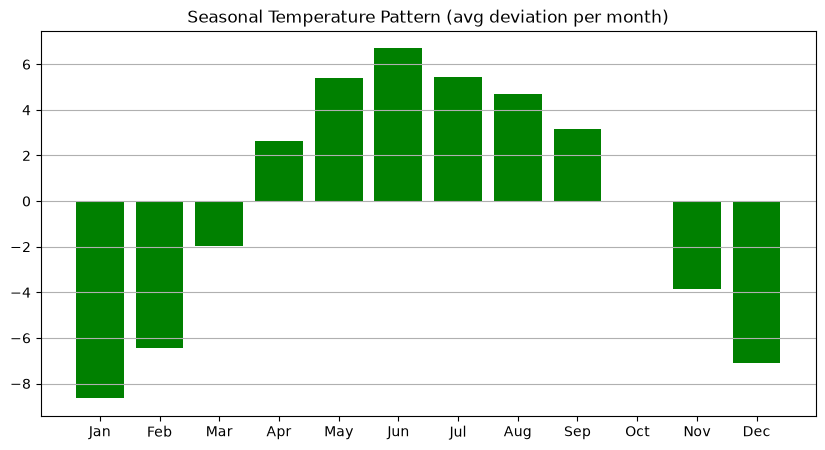

In [22]:
monthly_temp = df.groupby(['Year', 'Month'])['Temp_2m'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + monthly_temp['Month'].astype(str))
monthly_temp = monthly_temp.set_index('Date')['Temp_2m']

trend = monthly_temp.rolling(window=12, center=True).mean()
detrended = monthly_temp - trend
seasonal_by_month = detrended.groupby(detrended.index.month).mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 5))
plt.bar(month_names, seasonal_by_month.values, color='green')
plt.title('Seasonal Temperature Pattern (avg deviation per month)')
plt.grid(True, axis='y')

plt.savefig('seasonal_temperature_pattern.png', dpi=200, bbox_inches='tight')

plt.show()

### Observation 
june consistently comes out as the warmest point in the yearly cycle, and January the coldest- a clear signature of Nepal's monsoon-driven climate

### 7. Correlation Heatmap

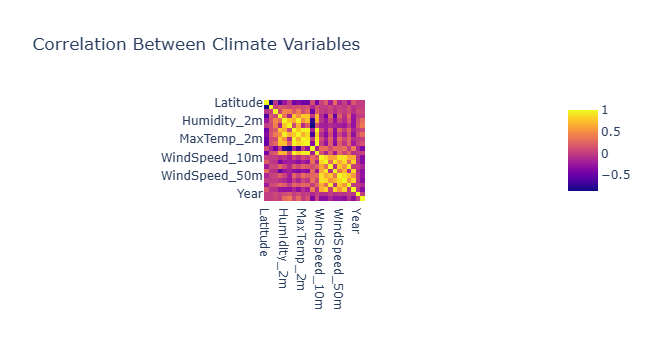

In [32]:
numeric = df.select_dtypes(include='number')

corr = numeric.corr()

fig = px.imshow(
    corr,
    text_auto=True,
    title="Correlation Between Climate Variables"
)
fig.show()

### Observation

This heatmap shows how strongly Nepal's climate variables relate to each other. Temperature-related 
columns (like Temp_2m, MaxTemp_2m, MinTemp_2m) correlate very strongly with each other, which makes 
sense since they're all measuring the same thing in slightly different ways. Humidity tends to show 
a negative relationship with temperature - hotter days are generally less humid.

### 8. Boxplot by District
Each district's 39 years of average temperatures are plotted as a boxplot, sorted from coldest to hottest, to comapre both typical temperature and year-to-year variability

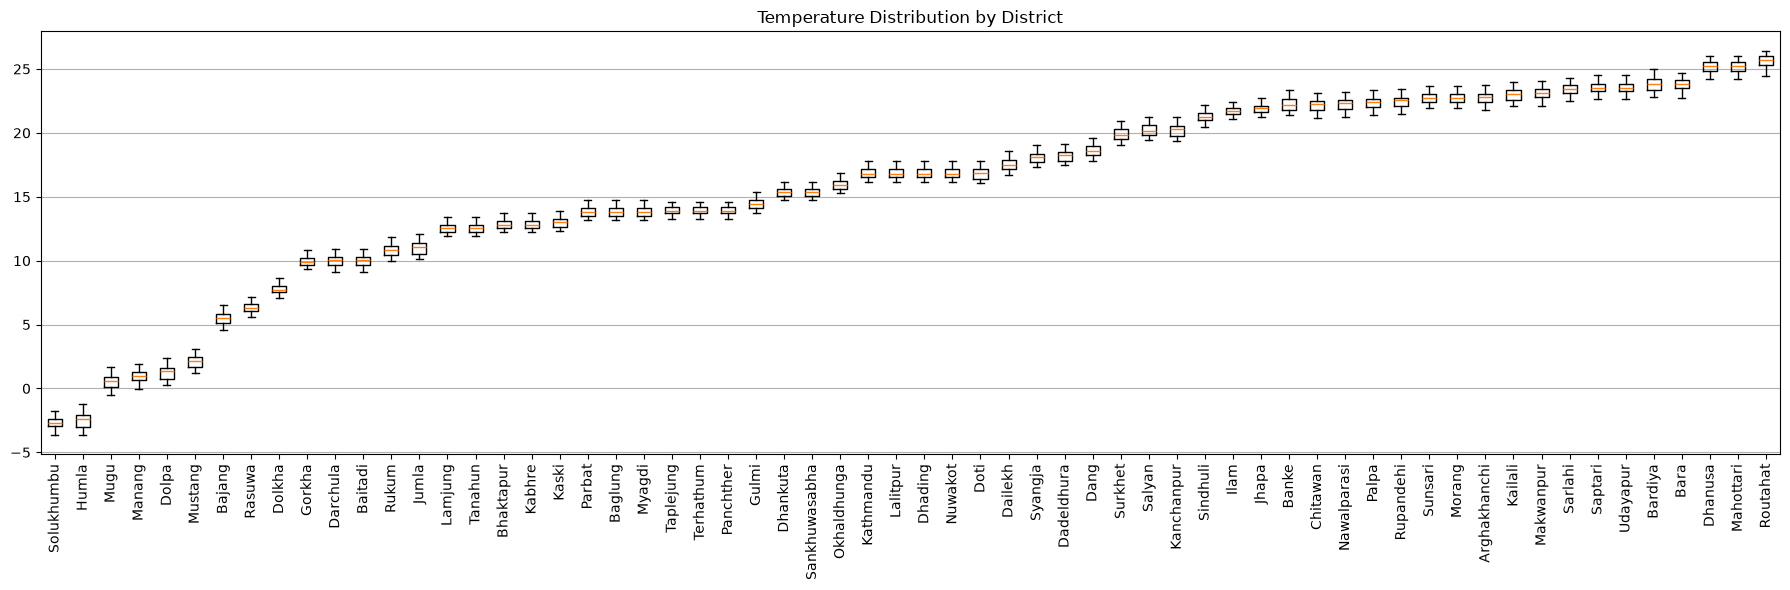

In [27]:
district_year_temp = df.groupby(['District', 'Year'])['Temp_2m'].mean().reset_index()
district_order = district_year_temp.groupby('District')['Temp_2m'].median().sort_values().index.tolist()

boxplot_data = [district_year_temp[district_year_temp['District'] == d]['Temp_2m'].values for d in district_order]

plt.figure(figsize=(18, 6))
plt.boxplot(boxplot_data, tick_labels=district_order)
plt.title('Temperature Distribution by District')
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('district_temperature_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

### Observation

The boxplot highlights the median temperature, the spread of the data, and potential outliers. 
This visualization helps identify unusual temperature values within the dataset.

### 9. Hottest Years Dtection 
Every year is compared against the 39-year average ('baseline') to find how far above or below normal it was, ranking the hottest years on record.

Year
1999    0.892543
2016    0.559299
1994    0.533431
1998    0.503579
2002    0.503400
Name: Temp_2m, dtype: float64


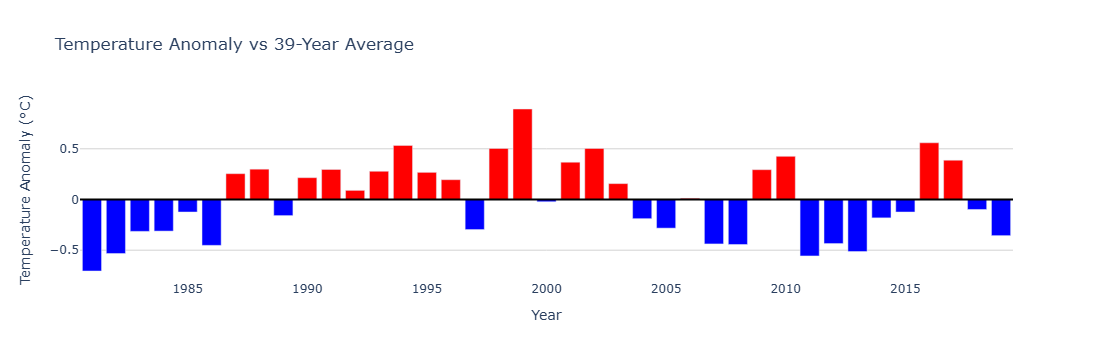

In [28]:
import plotly.graph_objects as go

baseline = yearly_temp.mean()
anomaly = yearly_temp - baseline
hottest_years = anomaly.sort_values(ascending=False).head(5)
print(hottest_years)

colors = ['red' if v >= 0 else 'blue' for v in anomaly.values]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=anomaly.index,
    y=anomaly.values,
    marker_color=colors,
    hovertemplate='Year: %{x}<br>Anomaly: %{y:.2f}°C<extra></extra>'
))
fig.add_hline(y=0, line_color='black')

fig.update_layout(
    title='Temperature Anomaly vs 39-Year Average',
    xaxis_title='Year',
    yaxis_title='Temperature Anomaly (°C)',
    yaxis=dict(gridcolor='lightgrey'),
    plot_bgcolor='white'
)
fig.show()

### Observation

1999, 2016, and 1994 stand out as the three hottest years relative to the 39-year baseline. 2016 aligns with a globally recognized strong El Nino year.

### 10. Temperature Trend Analysis

This section investigates how Nepal's average annual temperature has changed from 1981 to 2019.
Understanding long-term temperature trends is important for identifying possible climate changes over time.

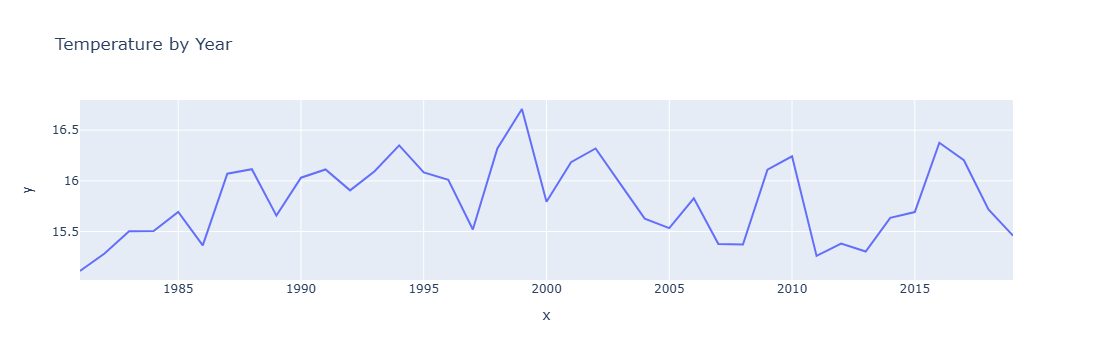

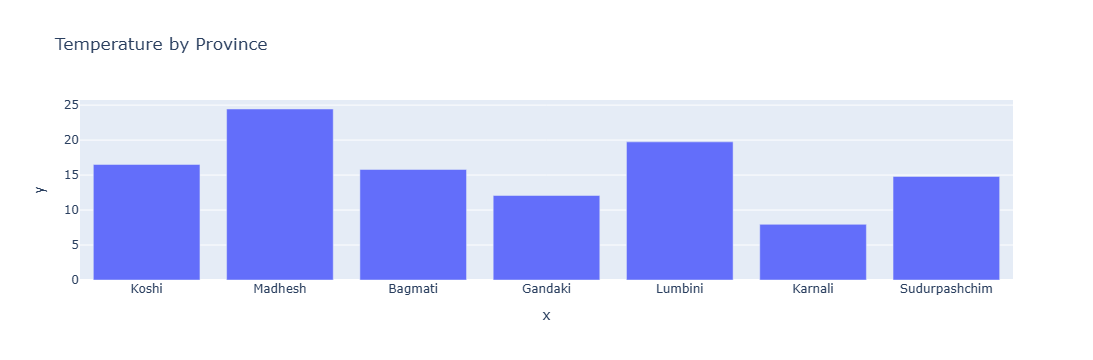

In [29]:
fig1 = px.line(x=yearly_temp.index, y=yearly_temp.values, title='Temperature by Year')
fig1.show()

fig2 = px.bar(x=province_temp.index, y=province_temp.values, title='Temperature by Province')
fig2.show()

### Observation

The visualization shows annual changes in average temperature throughout the study period. 
It helps identify long-term warming or cooling patterns as well as yearly fluctuations.

### 11. Climate Change Over Time

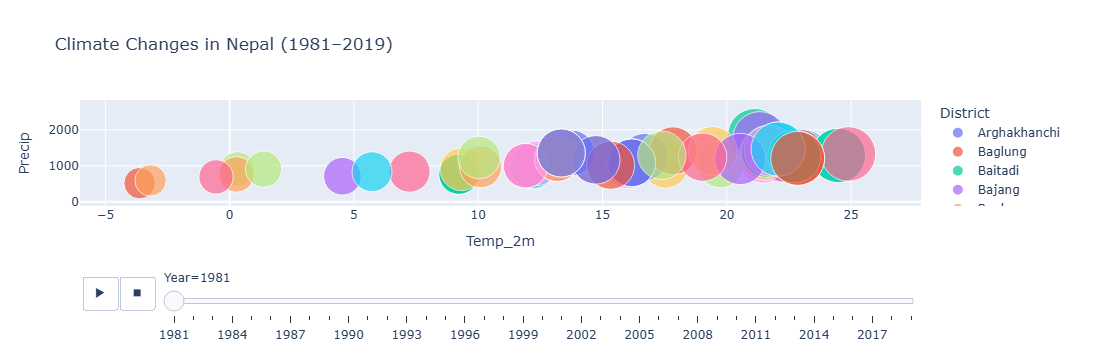

In [13]:
yearly = (
    df.groupby(["Year", "District"], as_index=False)
      .agg({
          "Temp_2m": "mean",
          "Precip": "sum",
          "Humidity_2m": "mean"
      })
)

fig = px.scatter(
    yearly,
    x="Temp_2m",
    y="Precip",
    animation_frame="Year",
    animation_group="District",
    size="Humidity_2m",
    color="District",
    hover_name="District",
    size_max=40,
    title="Climate Changes in Nepal (1981–2019)"
)

fig.show()

### Observation

To watch temperature, rainfall, and humidity shift year by year for every district at once, instead of viewing a single static snapshot.

### 12. Province and District Treemap

The following visualization compares districts within their respective provinces. 
It helps identify regional differences in average temperature across Nepal.

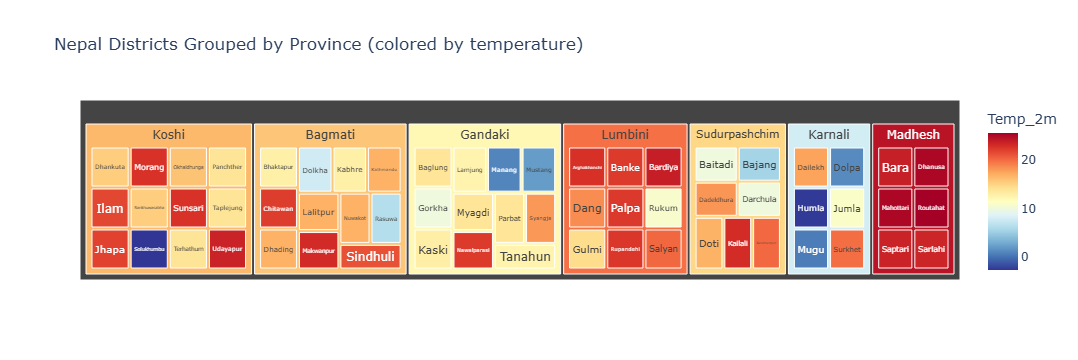

In [31]:
# Treemap - Province Overall, Districts Inside

# Get average temperature per district, keeping its province too
district_temp = df.groupby(['Province', 'District'])['Temp_2m'].mean().reset_index()

fig = px.treemap(
    district_temp,
    path=['Province', 'District'],
    values=[1] * len(district_temp),   # equal-sized boxes, since we're not adding temperatures up
    color='Temp_2m',
    color_continuous_scale='RdYlBu_r',
    title='Nepal Districts Grouped by Province (colored by temperature)'
)

fig.update_traces(textposition='middle center')
fig.show()

### Observation

The treemap groups districts according to their provinces. 
The colour intensity represents average temperature, making it easier to compare warmer and cooler regions across Nepal.

### Conclusion 
Overall, the analysis indicates a gradual increase in average temperature across Nepal, significant yearly rainfall variability, clear regional differences among provinces, and evidence that recent decades contain some of the hottest years in the dataset. These findings are consistent with broader discussions on climate change and demonstrate the usefulness of data analytics for environmental monitoring.